In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path_to_csvs   = '/home/gterren/india_power/gridpath_india_viz/csvs'
path_to_images = '/home/gterren/india_power/gridpath_india_viz/images'
path_to_input  = '/home/gterren/india_power/input_data'

In [2]:
tech_labels_ = pd.read_csv(path_to_csvs + '/technology_labels.csv') 
scenarios_   = pd.read_csv(path_to_csvs + '/ra-scenario_labels.csv') 

In [3]:
load_zones_ = pd.read_csv(path_to_input + r"/load_zones.csv").drop(columns = ['state', 'rps_zone'])

# Process projects characteristics

In [ ]:
# Load and processing projects characteristics in all iteratiions
def _processing_projects(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        print(path_to_scenarios)

        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_period.csv'), low_memory = False)

                df_ = df_[['technology', 
                           'load_zone', 
                           'capacity_mw', 
                           'stor_energy_capacity_mwh']].rename(columns = {'stor_energy_capacity_mwh': 'energy_mwh'})

                df_ = df_.groupby(['technology',
                                   'load_zone']).agg({'capacity_mw': 'sum',
                                                      'energy_mwh': 'sum'}).reset_index(drop = False)
            
                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group projects by technology
def _group_technology_in_project(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['technology', 
                        'load_zone']).agg({'capacity_mw': 'sum',
                                           'energy_mwh': 'sum'}).reset_index(drop = False)
# Load, process group projects
df_tech_ = _processing_projects(scenarios_)
df_tech_ = _group_technology_in_project(df_tech_, tech_labels_)
print(df_tech_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
  technology       load_zone    capacity_mw     energy_mwh
0    Battery  Andhra_Pradesh   57027.930263  120212.427495
1    Battery           Assam   69093.661964  427933.686023
2    Battery          

# Process project dispatch timepoints

In [5]:
# Load and processing project timepoints
def _processing_project_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), low_memory = False)

                df_ = df_[['timepoint', 
                           'technology', 
                           'load_zone', 
                           'capacity_mw',
                           'power_mw',
                           'starting_energy_mwh', 
                           'charge_mw', 
                           'discharge_mw', 
                           'total_curtailment_mw']] # availability_derate
               
                df_ = df_.groupby(['timepoint',
                                   'technology', 
                                   'load_zone']).agg({'capacity_mw': 'sum', 
                                                      'power_mw': 'sum',
                                                      'total_curtailment_mw': 'sum',
                                                      'starting_energy_mwh': 'sum',
                                                      'charge_mw': 'sum',
                                                      'discharge_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'total_curtailment_mw': 'curtailment_mw',
                                            'starting_energy_mwh': 'energy_mwh'})
                
                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

# Group project timepoints by technology
def _group_technology_in_project_timepoints(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 'technology'] = group
        
    return df_.groupby(['timepoint',
                        'technology', 
                        'load_zone',
                        'W-H-A']).agg({'capacity_mw': 'sum',
                                       'power_mw': 'sum',
                                       'curtailment_mw': 'sum',
                                       'energy_mwh': 'sum',
                                       'charge_mw': 'sum',
                                       'discharge_mw': 'sum'}).reset_index(drop = False)

# Load, process and group project timepoints
df_dispatch_ = _processing_project_timepoints(scenarios_)
df_dispatch_ = _group_technology_in_project_timepoints(df_dispatch_, tech_labels_)
print(df_dispatch_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint technology       load_zone     W-H-A  capacity_mw     power_mw  \
0  2040040101    Battery  Andhra_Pradesh     1-1-1  3168.218348     0.000000   
1  2040040101    Battery  Andhra_Prades

# Process system load timepoints

In [ ]:
# Load and processing system load timepoints
def _processing_system_load_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'system_load_zone_timepoint.csv'), 
                                  low_memory = False)
                
                df_ = df_[['timepoint', 
                           'load_zone', 
                           'static_load_mw',
                           'total_power_mw',
                           'net_imports_mw', 
                           'overgeneration_mw', 
                           'unserved_energy_mw']]
                
                df_ = df_.groupby(['timepoint',
                                   'load_zone']).agg({'static_load_mw': 'sum',
                                                      'total_power_mw': 'sum',
                                                      'net_imports_mw': 'sum',
                                                      'overgeneration_mw': 'sum',
                                                      'unserved_energy_mw': 'sum'}).reset_index(drop = False)
                
                df_ = df_.rename(columns = {'static_load_mw': 'static_load',
                                            'total_power_mw': 'total_power',
                                            'net_imports_mw': 'net_imports',
                                            'overgeneration_mw': 'overgeneration',
                                            'unserved_energy_mw': 'unserved_energy'})
                
                df_ = pd.melt(df_, id_vars = ['timepoint', 
                                              'load_zone'], 
                                value_vars = ['static_load', 
                                              'total_power',
                                              'net_imports',
                                              'overgeneration',
                                              'unserved_energy'], 
                                var_name   = 'technology', 
                                value_name = 'power_mw')
                
                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_)

    return pd.concat(dfs_).reset_index(drop = True)

df_load_ = _processing_system_load_timepoints(scenarios_)
print(df_load_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8
capex_pier_prm_108_cc_90_hardovergen_2040_9
capex_pier_prm_108_cc_90_hardovergen_2040_10
capex_pier_prm_108_cc_90_hardovergen_2040_11
capex_pier_prm_108_cc_90_hardovergen_2040_12
capex_pier_prm_108_cc_90_hardovergen_2040_13
capex_pier_prm_108_cc_90_hardovergen_2040_14
capex_pier_prm_108_cc_90_hardovergen_2040_15
capex_pier_prm_108_cc_90_hardovergen_2040_16
capex_pier_prm_108_cc_90_hardovergen_2040_17
capex_pier_prm_108_cc_90_hardovergen_2040_18
    timepoint          load_zone   technology      power_mw  W-H-A
0  2040040101     Andhra_Pradesh  static_load  20069.969633  1-1-1
1  2040040101  Arunachal_Pradesh  static_load    159.953926  1-1-

## Filter energy dispatch by `timepoint`, `load_zone` and `iterations`

In [19]:
def _filter_dispatch_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W-H-A'] == WHA) 
    idx_3_ = df_['load_zone'].isin(load_zones_)

    df_ = df_[idx_1_ & idx_2_ & idx_3_].reset_index(drop = True)
    df_ = df_[['timepoint', 
               'technology', 
               'power_mw',
               'energy_mwh', 
               'charge_mw', 
               'discharge_mw', 
               'curtailment_mw']]

    return df_.groupby(['timepoint', 
                        'technology']).agg({'power_mw': 'sum',
                                            'energy_mwh': 'sum',
                                            'charge_mw': 'sum',
                                            'discharge_mw': 'sum',
                                            'curtailment_mw': 'sum'}).reset_index(drop = False).copy()
    
def _filter_load_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W-H-A'] == WHA) 
    idx_3_ = df_['load_zone'].isin(load_zones_)

    df_ = df_[idx_1_ & idx_2_ & idx_3_].reset_index(drop = True)
    df_ = df_[['timepoint', 
               'technology', 
               'power_mw']]

    return df_.groupby(['timepoint', 
                        'technology']).agg({'power_mw': 'sum'}).reset_index(drop = False).copy()
    

# # Load zone to be analyzed
# #load_zones_ = load_zones_p_.loc[load_zones_p_['region'] == 'Eastern', 'load_zone'].to_numpy()
# #load_zones_ = load_zones_p_.loc[[1, 2, 3], 'load_zone'].to_numpy()

# Load zone to be analyzed
load_zones_ = ['Delhi']

# Begining and ending timepoints
timepoint_0 = 2041010101
timepoint_1 = 2041010724

# Iteration descriptors
WHA = '17-17-17'

# # Load zone to be analyzed
# load_zones_ = ['Odisha']

# # Begining and ending timepoints
# timepoint_0 = 2040100801
# timepoint_1 = 2040101324

# # Iteration descriptors
# WHA = '18-18-18'

# # Load zone to be analyzed
# load_zones_ = ['Karnataka']

# # Begining and ending timepoints
# timepoint_0 = 2041020101
# timepoint_1 = 2041020824

# # Iteration descriptors
# WHA = '17-17-17'

df_dispatch_p_ = _filter_dispatch_timepoints(df_dispatch_, load_zones_, timepoint_0, timepoint_1, WHA)
df_load_p_     = _filter_load_timepoints(df_load_, load_zones_, timepoint_0, timepoint_1, WHA)
print(df_dispatch_p_)
print(df_load_p_)



      timepoint technology     power_mw    energy_mwh    charge_mw  \
0    2041010101    Battery     0.000000   5049.455435     0.000000   
1    2041010101        Gas     0.000000      0.000000     0.000000   
2    2041010101   Hydrogen     0.000000      0.000000     0.000000   
3    2041010101      Solar     0.000000      0.000000     0.000000   
4    2041010102    Battery -1765.518424   5049.455435  1765.518424   
..          ...        ...          ...           ...          ...   
667  2041010723      Solar     0.000000      0.000000     0.000000   
668  2041010724    Battery     0.000000  10201.951352     0.000000   
669  2041010724        Gas  2199.400770      0.000000     0.000000   
670  2041010724   Hydrogen     0.000000      0.000000     0.000000   
671  2041010724      Solar     0.000000      0.000000     0.000000   

     discharge_mw  curtailment_mw  
0             0.0             0.0  
1             0.0             0.0  
2             0.0             0.0  
3             0

    timepoint          load_zone   technology      power_mw  W-H-A
0  2040040101     Andhra_Pradesh  static_load  20069.969633  1-1-1
1  2040040101  Arunachal_Pradesh  static_load    159.953926  1-1-1
2  2040040101              Assam  static_load   2328.118759  1-1-1
3  2040040101             Bhutan  static_load      0.000000  1-1-1
4  2040040101              Bihar  static_load   5356.685017  1-1-1
['static_load' 'total_power' 'net_imports' 'overgeneration'
 'unserved_energy']


Index(['timepoint', 'technology', 'power_mw'], dtype='object')
['net_imports' 'overgeneration' 'static_load' 'total_power'
 'unserved_energy']
4269.214446203568 17777.76148883916


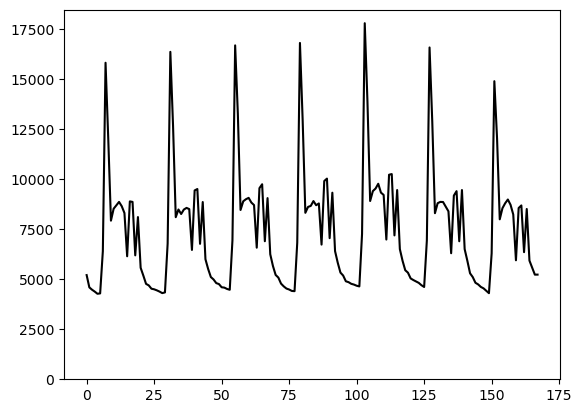

In [22]:
print(df_load_p_.columns)

print(df_load_p_['technology'].unique())

static_load_ = df_load_p_.loc[df_load_p_['technology'] == 'static_load'].reset_index(drop = True).sort_values(by='timepoint')
print(static_load_['power_mw'].min(), static_load_['power_mw'].max())

plt.figure()
plt.plot(static_load_['power_mw'], label='Static Load', color='black')
plt.ylim(0,)
plt.show()

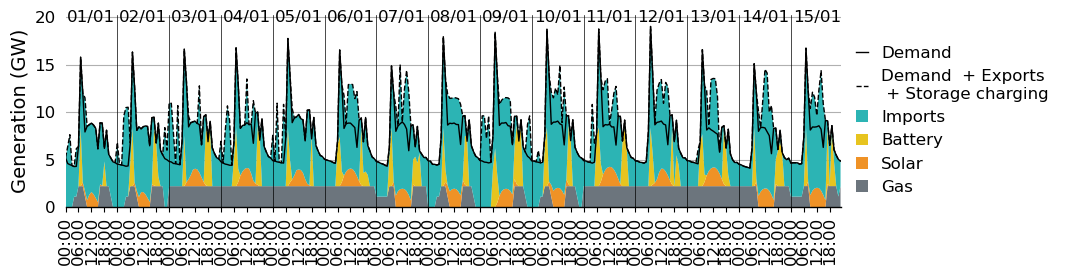

In [11]:
# Plot energy dispatch for a given day
def _plot_energy_dispatch(ax, df_1_, df_2_, tech_labels_, 
                          ylabel = r'Generation (GWh)',
                          title  = '',
                          units  = 1e3,
                          xlabel = True,
                          legend = True):
    
    def _make_dispatch_legend(ax, df_, techs_):

        for i_tech in np.sort(np.unique(techs_['order']))[::-1]:
            tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
            color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]
            idx_  = df_['technology'] == tech
            if idx_.sum() > 0:
                if df_.loc[idx_, 'power_mw'].to_numpy().sum() != 0:
                    ax.bar(0., 0., 0., 
                           bottom = 0.,
                           color  = color,
                           label  = tech.replace('_', ' '),
                           zorder = 2,
                           ec     = 'None',
                           lw     = 0.,
                           aa     = True)

    def _processing_technology_dispatch(df_, x_, tech_labels_, colors_, dispatch_, color, tech, 
                                        dispatch = True):

        idx_ = (df_['technology'] == tech) 

        x_p_ = df_.loc[idx_, 'timepoint'].to_numpy().astype(int).astype(str)
        y_   = df_.loc[idx_, 'power_mw'].to_numpy()/units

        if dispatch:
            idx_ = y_ > 0.
        else:
            idx_ = y_ < 0.

        if idx_.sum() > 0.:
            y_p_  = np.zeros((x_.shape[0],))
            x_p_  = x_p_[idx_]
            y_    = y_[idx_]
            
            for x_p in x_p_:
                if (x_ == x_p).sum() == 1:
                    y_p_[x_ == x_p] = y_[x_p_ == x_p]

            colors_.append(color)
            dispatch_.append(y_p_)

        return dispatch_, colors_

    df_1_p_ = df_1_[['timepoint', 
                     'technology', 
                     'power_mw']].copy()
    
    df_2_p_ = df_2_[['timepoint', 
                     'technology', 
                     'power_mw']].copy()

    df_ = pd.concat([df_1_p_, df_2_p_.loc[df_2_p_['technology'] == 'net_imports']], axis = 0).reset_index(drop = True)
    df_ = pd.concat([df_, df_2_p_.loc[df_2_p_['technology'] == 'unserved_energy']], axis = 0).reset_index(drop = True)

    df_.loc[df_['technology'] == 'net_imports', 'technology'] = 'Imports'
    df_.loc[df_['technology'] == 'unserved_energy', 'technology'] = 'Shedding'

    x_labels_ = np.sort(df_['timepoint'].unique().astype(int)).astype(str)
    x_ = np.arange(x_labels_.shape[0])

    _make_dispatch_legend(ax, df_, tech_labels_)

    colors_   = []
    dispatch_ = []
    for i_tech in np.sort(np.unique(tech_labels_['order'])):
        tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
        color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]

        dispatch_, colors_ = _processing_technology_dispatch(df_, x_labels_, tech_labels_, colors_, dispatch_, 
                                                             color, tech)
    Y_ = np.vstack(dispatch_)
    ax.stackplot(x_, Y_, 
                 colors = colors_, 
                 zorder = 10, 
                 lw     = 0.)

    colors_   = []
    dispatch_ = []
    for i_tech in np.sort(np.unique(tech_labels_['order'])):        
        tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
        color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]
        dispatch_, colors_ = _processing_technology_dispatch(df_, x_labels_, tech_labels_, colors_, dispatch_, 
                                                             color, tech, dispatch = False)

    discharge_ = np.sum(np.vstack(dispatch_), axis = 0)
    ax.stackplot(x_, np.vstack(dispatch_), 
                 colors = colors_, 
                 zorder = 10, 
                 lw     = 0.)
    
    load_  = df_2_p_.loc[df_2_p_['technology'] == 'static_load', 'power_mw'].to_numpy()/units
    # total_ = df_2_.loc[df_2_['technology'] == 'total_power', 'power_mw'].to_numpy()/units
    net_ = df_2_.loc[df_2_['technology'] == 'net_imports', 'power_mw'].to_numpy()/units

    ax.plot(x_, load_, color     = 'k', 
                       linestyle = '-', 
                       label     = 'Demand',
                       lw        = 1., 
                       alpha     = 1., 
                       zorder    = 11)
    
    ax.plot(x_, load_ - discharge_, 
            color     = 'k', 
            linestyle = '--', 
            label     = 'Demand  + Exports \n + Storage charging',
            lw        = 1., 
            alpha     = 1., 
            zorder    = 11)

    ax.set_ylabel(ylabel, fontsize = 14)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    
    ax.set_xticks(x_[::6], ['{:02}:00'.format(int(x_label[-2:]) - 1)
                             for x_label in x_labels_][::6], rotation = 90)
    
    for x, x_label in zip(x_[12::24], x_labels_[12::24]):
        ax.text(x, np.sum(Y_, axis = 0).max()*1.05, 
                f'{x_label[-4:-2]}/{x_label[-6:-4]}', ha='center', va='center', size = 12)
        
    for x in x_[24::24]:
        ax.axvline(x, linewidth = .5, 
                      linestyle = '-', 
                      color     = 'k', 
                      clip_on   = False, 
                      zorder    = 10)
    
    ax.axhline(0, linewidth = 1., 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)

    ax.set_xlim(x_[0], x_[-1])
    ax.set_ylim(0, )

    if legend:
        ax.legend(loc            = 'center left', 
                  bbox_to_anchor = (1., 0.45), 
                  handlelength   = .75,
                  frameon        = False,
                  prop           = {'size': 12})
        
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')

fig = plt.figure(figsize = (10, 2.5))
_ax = plt.subplot(111)

_plot_energy_dispatch(_ax, df_dispatch_p_, df_load_p_, tech_labels_, 
                      ylabel = r'Generation (GW)',
                      title  = '',
                      units  = 1e3)

plt.savefig(path_to_images + r'/dispatch-{}-{}-{}-{}.pdf'.format(load_zones_, timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/dispatch-{}-{}-{}-{}.png'.format(load_zones_, timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

NameError: name 'load_zone' is not defined

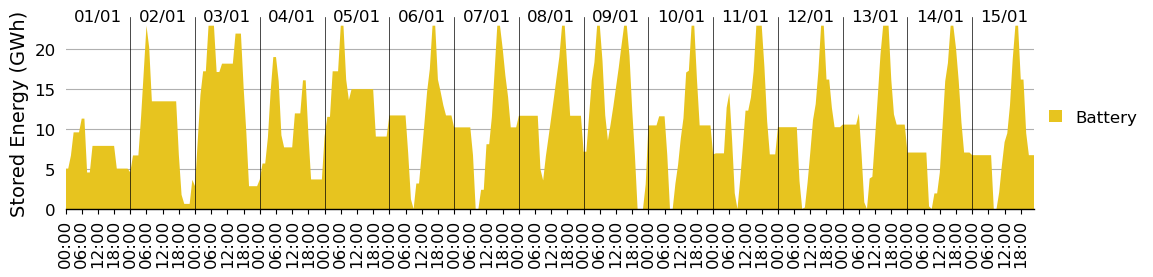

In [9]:
# Plot energy dispatch for a given day
def _plot_state_of_charge(ax, df_, tech_labels_, 
                          ylabel = r'Energy (GWh)',
                          title  = '',
                          units  = 1e3,
                          xlabel = True,
                          legend = True):
    
    def _make_soc_legend(ax, df_, techs_):

        for i_tech in np.sort(np.unique(techs_['order']))[::-1]:
            tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
            color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]
            idx_  = df_['technology'] == tech
            if idx_.sum() > 0:
                if df_.loc[idx_, 'energy_mwh'].to_numpy().sum() != 0:
                    ax.bar(0., 0., 0., 
                           bottom = 0.,
                           color  = color,
                           label  = tech.replace('_', ' '),
                           zorder = 2,
                           ec     = 'None',
                           lw     = 0.,
                           aa     = True)

    def _processing_technology_soc(df_, x_, tech_labels_, colors_, dispatch_, color, tech):

        idx_ = (df_['technology'] == tech) 

        x_p_ = df_.loc[idx_, 'timepoint'].to_numpy().astype(int).astype(str)
        y_   = df_.loc[idx_, 'energy_mwh'].to_numpy()/units

        idx_ = y_ > 0.

        if idx_.sum() > 0.:
            y_p_  = np.zeros((x_.shape[0],))
            x_p_  = x_p_[idx_]
            y_    = y_[idx_]
            
            for x_p in x_p_:
                if (x_ == x_p).sum() == 1:
                    y_p_[x_ == x_p] = y_[x_p_ == x_p]

            colors_.append(color)
            dispatch_.append(y_p_)

        return dispatch_, colors_
    
    df_ = df_.loc[df_['technology'].isin(['Battery', 
                                          'Hydrogen', 
                                          'Pumped_Hydro'])].reset_index(drop = True)

    x_labels_ = np.sort(df_['timepoint'].unique().astype(int)).astype(str)
    x_ = np.arange(x_labels_.shape[0])

    _make_soc_legend(ax, df_, tech_labels_)

    colors_   = []
    dispatch_ = []
    for i_tech in np.sort(np.unique(tech_labels_['order'])):
        tech  = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group'].unique()[0]
        color = tech_labels_.loc[tech_labels_['order'] == i_tech, 'group_color'].unique()[0]

        dispatch_, colors_ = _processing_technology_soc(df_, x_labels_, tech_labels_, colors_, dispatch_, 
                                                             color, tech)
        
    Y_ = np.vstack(dispatch_)
    ax.stackplot(x_, Y_, 
                 colors = colors_, 
                 zorder = 10, 
                 lw     = 0.)

    ax.set_ylabel(ylabel, fontsize = 14)

    ax.xaxis.set_tick_params(labelsize = 12)
    ax.yaxis.set_tick_params(labelsize = 12, left = False)
    
    ax.set_xticks(x_[::6], ['{:02}:00'.format(int(x_label[-2:]) - 1)
                             for x_label in x_labels_][::6], rotation = 90)

    for x, x_label in zip(x_[12::24], x_labels_[12::24]):
        ax.text(x, np.sum(Y_, axis = 0).max()*1.05, f'{x_label[-4:-2]}/{x_label[-6:-4]}', 
                ha   = 'center', 
                va   = 'center', 
                size = 12)

    for x in x_[24::24]:
        ax.axvline(x, linewidth = .5, 
                      linestyle = '-', 
                      color     = 'k', 
                      clip_on   = False, 
                      zorder    = 10)
        
    ax.axhline(0, linewidth = 1., 
                  linestyle = '-', 
                  color     = 'k', 
                  clip_on   = False, 
                  zorder    = 10)

    ax.set_xlim(x_[0], x_[-1])
    ax.set_ylim(0)

    if legend:
        ax.legend(loc            = 'center left', 
                  bbox_to_anchor = (1., 0.475), 
                  handlelength   = .75,
                  frameon        = False,
                  prop           = {'size': 12})
        
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.grid(axis = 'y')

fig = plt.figure(figsize = (12.5, 2.5))
_ax = plt.subplot(111)

_plot_state_of_charge(_ax, df_dispatch_p_, tech_labels_, 
                      ylabel = r'Stored Energy (GWh)',
                      title  = '',
                      units  = 1e3)

plt.savefig(path_to_images + r'/soc-{}-{}-{}-{}.pdf'.format(load_zone, timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/soc-{}-{}-{}-{}.png'.format(load_zone, timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [ ]:
# Load and processing project timepoints
def _processing_project_cf_timepoints(scenarios_):

    dfs_ = []
    for scenario, path_to_scenarios in zip(scenarios_['scenario'], scenarios_['path']):
        path_to_scenario = os.path.join(path_to_scenarios, scenario)

        for dirpath, dirnames, filenames in os.walk(path_to_scenario):
            # Processing scenarios results folder only
            if dirpath.split('/')[-1] == 'results':
                print(scenario)

                df_ = pd.read_csv(os.path.join(dirpath, 'project_timepoint.csv'), 
                                  low_memory = False)

                df_ = df_[['timepoint', 
                           'project', 
                           'technology', 
                           'load_zone', 
                           'capacity_mw',
                           'power_mw']] # availability_derate
                
                df_['CF'] = df_['power_mw']/df_['capacity_mw']

                # Add iteration descriptors to dataframe
                df_['W-H-A'] = r'{}-{}-{}'.format(dirpath.split('/')[-4].split('_')[-1], 
                                                  dirpath.split('/')[-3].split('_')[-1], 
                                                  dirpath.split('/')[-2].split('_')[-1])
                
                dfs_.append(df_[['timepoint',
                                 'project', 
                                 'technology', 
                                 'load_zone', 
                                 'capacity_mw',
                                 'CF', 
                                 'W-H-A']])

    return pd.concat(dfs_).reset_index(drop = True)

# Group projects by technology
def _rename_technology(df_, tech_labels_):

    for group in tech_labels_['group'].unique():
        df_.loc[df_['technology'].isin(tech_labels_.loc[tech_labels_['group'] == group, 'technology']), 
                'technology'] = group
        
    return df_

# Load, process and group project timepoints
df_proj_dispatch_ = _processing_project_cf_timepoints(scenarios_)
df_proj_dispatch_ = _rename_technology(df_proj_dispatch_, tech_labels_)
print(df_proj_dispatch_.head())

capex_pier_prm_108_cc_90_hardovergen_2040_1
capex_pier_prm_108_cc_90_hardovergen_2040_2
capex_pier_prm_108_cc_90_hardovergen_2040_3
capex_pier_prm_108_cc_90_hardovergen_2040_4
capex_pier_prm_108_cc_90_hardovergen_2040_5
capex_pier_prm_108_cc_90_hardovergen_2040_6
capex_pier_prm_108_cc_90_hardovergen_2040_7
capex_pier_prm_108_cc_90_hardovergen_2040_8


KeyboardInterrupt: 

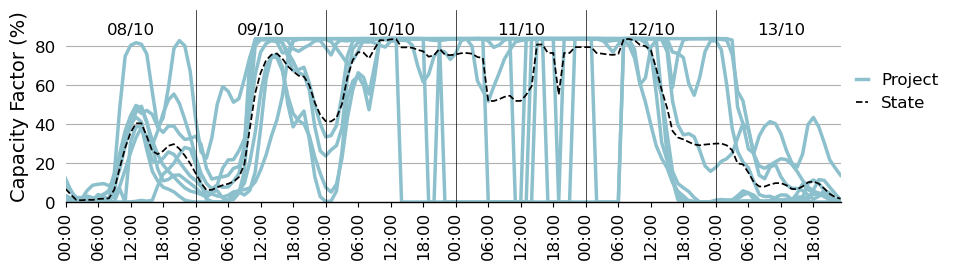

In [ ]:
# Plot energy dispatch for a given day
def _plot_capacity_factors(ax, df_, tech_labels_, 
                           ylabel = r'Energy (GWh)',
                           title  = '',
                           units  = 1e3,
                           xlabel = True,
                           legend = True):
    
        df_p_ = df_.groupby(['timepoint']).agg({'power_mw': 'sum',
                                                'capacity_mw': 'sum'}).reset_index(drop = False)
        
        x_labels_ = np.sort(df_['timepoint'].unique().astype(int)).astype(str)
        x_ = np.arange(x_labels_.shape[0])

        for project in df_['project'].unique():
                idx_  = df_['project'] == project
                tech  = df_.loc[idx_, 'technology'].unique()[0]
                color = tech_labels_.loc[tech_labels_['group'] == tech, 'group_color'].unique()[0]

                cap  = df_.loc[idx_, 'capacity_mw'].unique()[0]

                if cap > 0.: 
                        ax.plot(x_, 100.*df_.loc[idx_, 'CF'], lw = 2.5, c = color, clip_on = True)        

        ax.plot(x_, 100.*df_.loc[idx_, 'CF'], lw = 2.5, c = color, clip_on = True, label = 'Project')
        ax.plot(x_, 100.*df_p_['power_mw']/df_p_['capacity_mw'], lw = 1.25, c = 'k', ls = '--', clip_on = True, 
                label = 'State')

        ax.set_ylabel(ylabel, fontsize = 14)

        ax.xaxis.set_tick_params(labelsize = 12)
        ax.yaxis.set_tick_params(labelsize = 12, left = False)

        ax.set_xticks(x_[::6], ['{:02}:00'.format(int(x_label[-2:]) - 1)
                                for x_label in x_labels_][::6], rotation = 90)

        for x, x_label in zip(x_[12::24], x_labels_[12::24]):
                ax.text(x, 100.*df_['CF'].max()*1.05, f'{x_label[-4:-2]}/{x_label[-6:-4]}', 
                        ha   = 'center', 
                        va   = 'center', 
                        size = 12)
                                        
        ax.axhline(0, linewidth = 1., 
                        linestyle = '-', 
                        color     = 'k', 
                        clip_on   = False, 
                        zorder    = 10)

        if legend:
                ax.legend(#loc            = 'center right', 
                          bbox_to_anchor = (1., 0.75), 
                          handlelength   = .75,
                          frameon        = False,
                          prop           = {'size': 12})

        for x in x_[24::24]:
                ax.axvline(x, linewidth = .5, 
                                linestyle = '-', 
                                color     = 'k', 
                                clip_on   = False, 
                                zorder    = 10)
                
        ax.set_xlim(x_[0], x_[-1])
        ax.set_ylim(0, 99)

        ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
        ax.grid(axis = 'y')


def _filter_timepoints(df_p_, load_zones_, timepoint_0, timepoint_1, WHA):

    df_ = df_p_.copy()

    # Selecting timepoints, iteration, and load zone
    idx_1_ = (df_['timepoint'] >= timepoint_0) & (df_['timepoint'] <= timepoint_1) 
    idx_2_ = (df_['W-H-A'] == WHA) 
    idx_3_ = df_['load_zone'].isin(load_zones_)

    return df_[idx_1_ & idx_2_ & idx_3_].reset_index(drop = True).sort_values('timepoint').copy()

# Load zone to be analyzed
load_zones_ = ['Odisha']

# Begining and ending timepoints
timepoint_0 = 2040100801
timepoint_1 = 2040101324

# Iteration descriptors
WHA = '18-18-18'

techs_ = ['Wind']

df_proj_dispatch_p_ = _filter_timepoints(df_proj_dispatch_, load_zones_, timepoint_0, timepoint_1, WHA)
df_                 = df_proj_dispatch_p_.loc[df_proj_dispatch_p_['technology'].isin(techs_)].reset_index(drop = True).copy()
df_['power_mw']     = df_['CF'] * df_['capacity_mw']

fig = plt.figure(figsize = (10, 2.5))
ax = plt.subplot(111)

_plot_capacity_factors(ax, df_, tech_labels_, ylabel = 'Capacity Factor (%)', legend = True)

plt.savefig(path_to_images + r'/cf-{}-{}-{}.pdf'.format(timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.savefig(path_to_images + r'/cf-{}-{}-{}.png'.format(timepoint_0, timepoint_1, WHA), 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()

In [7]:

# # Expected Unserved Energy
# def _EUE(L_net_):
#     N_days, N_years = L_net_.shape
#     EUE_ = np.zeros((N_years,))
#     for i in range(N_years):
#         EUE_[i] = np.sum(L_net_[L_net_[:, i] > 0., i])
#     return np.mean(EUE_)

# # Expected Unmet Energy Fraction
# def _EUEF(L_, L_net_):
#     N_days, N_years = L_net_.shape
#     EUEF_ = np.zeros((N_years,))
#     for i in range(N_years):
#         EUEF_[i] = np.mean( L_net_[L_net_[:, i] > 0., i] / L_[L_net_[:, i] > 0., i])
#     return np.mean(EUEF_)
 
# # Loss-of-Load Duration
# def _LOLD(L_net_, LOLF):
#     N_days, N_years = L_net_.shape
#     LOLH_ = np.zeros((N_years,))
#     for i in range(N_years):
#         LOLH_[i] = np.sum(L_net_[:, i] > 0)
#     return np.nan_to_num(np.mean(LOLH_)/LOLF, 0)

# # Loss-Of-Load-Expectation
# def _LOLE(L_net_):
#     N_hours_year, N_years = L_net_.shape
#     N_days = int(N_hours_year/24)
#     L_net_prime_ = np.reshape(L_net_, (N_days, 24, N_years))
#     LOLE = 0.
#     for i in range(N_years):
#         for j in range(N_days):
#             if (L_net_prime_[j, :, i] > 0.).sum() > 0:
#                 LOLE += 1.
#     return LOLE/N_years

# # Loss-of-Load Frequency
# def _LOLF(L_net_):
#     N_days, N_years = L_net_.shape
#     LOLF_    = np.zeros((N_years,))
#     L_net_p_ = 1.*(L_net_ > 0)
#     for i in range(N_years):
#         prev = 0.
#         for j in range(N_days):
#             if (L_net_p_[j, i] == 1.) and (prev == 0.):
#                 LOLF_[i] += 1
#             prev = L_net_p_[j, i]
#     return np.mean(LOLF_)

# # Loss-of-Load Hours
# def _LOLH(L_net_):
#     N_days, N_years = L_net_.shape
#     LOLH_ = np.zeros((N_years,))
#     for i in range(N_years):
#         LOLH_[i] = np.sum(L_net_[:, i] > 0)
#     return np.mean(LOLH_)

# # Loss-of-Load Probability
# def _LOLP(L_net_):
#     N_days, N_years = L_net_.shape
#     LOLP_ = np.zeros((N_years,))
#     for i in range(N_years):
#         LOLP_[i] = np.sum(L_net_[:, i] > 0)/N_days
#     return np.mean(LOLP_)*100.


In [8]:
# def _calculate_events(df_p_):
#     df_ = df_p_.copy()

#     df_['is_lol']    = df_['power_mw'] > 0.
#     df_['lol_start'] = (~df_['is_lol'].shift(fill_value=False)) & df_['is_lol']
#     df_['event_id']  = df_['lol_start'].cumsum()

#     print(df_[df_['is_lol']].groupby('event_id').size().values)

#     return

# # for w in df['weather_iteration'].unique():
# #     sub = df[df['weather_iteration'] == w].sort_values('timestamp')
# #     sub['event_id'] = sub['lol_start'].cumsum()
# #     durations = sub[sub['is_lol']].groupby('event_id').size().values
# #     all_durations.extend(durations)


# df_load_sts_ = df_load_.loc[df_load_['technology'] == 'unserved_energy'].reset_index(drop = True)

# df_load_nt_ = df_load_sts_.groupby(['timepoint',
#                                     'technology',
#                                     'W-H-A']).agg({'power_mw': 'sum'}).reset_index(drop = False)

# # for load_zone in df_load_sts_['load_zone'].unique():
# #     print(load_zone)
# #     for W in df_load_sts_['W'].unique():
# #         idx_1_      = df_load_sts_['load_zone'] == load_zone
# #         idx_2_      = (df_load_sts_['W'] == W)
# #         idx_        = idx_1_ & idx_2_
# #         df_load_st_ = df_load_sts_.loc[idx_].reset_index(drop = True).sort_values('timepoint')

# #         if df_load_st_['power_mw'].sum() > 0: 
# #             df_ = _calculate_events(df_load_st_)